**Siamese Network One-Shot**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import  numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
df = pd.read_csv('reference_subset_1_resampled.csv')
labels = df['Label'].values
raw_specs = df.drop(columns=['Label']).values.astype(float)

In [4]:
lam, p, niter = 1e4, 0.01, 10
def baseline_als(y):
    L = len(y)
    D = np.diff(np.eye(L), 2)
    D = lam * D.dot(D.T)
    w = np.ones(L)
    for _ in range(niter):
        b = np.linalg.solve(np.diag(w) + D, w * y)
        w = p * (y > b) + (1 - p) * (y < b)
    return b

def preprocess(arr):
    out = np.zeros_like(arr)
    for i, s in enumerate(arr):
        b = baseline_als(s)
        c = s - b
        norm = np.linalg.norm(c)
        out[i] = c / norm if norm > 0 else c
    return out

In [5]:
spectra = preprocess(raw_specs)

In [6]:
def augment(spec, noise_std=0.01, shift_max=2):
    spec_noisy = spec + np.random.normal(0, noise_std, size=spec.shape)
    shift = np.random.randint(-shift_max, shift_max + 1)
    return np.roll(spec_noisy, shift)

# 3. Pair dataset for contrastive learning
class RamanPairDataset(Dataset):
    def __init__(self, specs, labels, augment_fn=None):
        self.specs = specs
        self.labels = labels
        self.augment = augment_fn
        self.by_label = {c: np.where(labels == c)[0] for c in np.unique(labels)}

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        x1 = self.specs[idx]
        y1 = self.labels[idx]
        if np.random.rand() < 0.5:
            j = np.random.choice(self.by_label[y1])
            label = 1.0
        else:
            neg = [c for c in self.by_label if c != y1]
            y2 = np.random.choice(neg)
            j = np.random.choice(self.by_label[y2])
            label = 0.0
        x2 = self.specs[j]
        if self.augment:
            x1 = self.augment(x1)
            x2 = self.augment(x2)
        return (torch.tensor(x1, dtype=torch.float32).unsqueeze(0),
                torch.tensor(x2, dtype=torch.float32).unsqueeze(0),
                torch.tensor(label, dtype=torch.float32))

# 4. Siamese network definition
class SiameseNet(nn.Module):
    def __init__(self, input_len, embed_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear((input_len // 4) * 32, embed_dim),
            nn.ReLU()
        )

    def forward(self, x):
        z = self.encoder(x)
        return F.normalize(z, dim=1)

# 5. Contrastive loss
def contrastive_loss(z1, z2, label, margin=1.0):
    dist = F.pairwise_distance(z1, z2)
    loss_pos = label * dist**2
    loss_neg = (1 - label) * F.relu(margin - dist)**2
    return (loss_pos + loss_neg).mean()

In [10]:
input_len = spectra.shape[1]
dataset = RamanPairDataset(spectra, labels, augment_fn=augment)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
model = SiameseNet(input_len, embed_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(100):
    total_loss = 0.0
    for x1, x2, lbl in loader:
        z1, z2 = model(x1), model(x2)
        loss = contrastive_loss(z1, z2, lbl)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x1.size(0)
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Save the trained model
torch.save(model.state_dict(), "siamese_raman_resampled.pth")

Epoch 1, Loss: 0.4189
Epoch 2, Loss: 0.4235
Epoch 3, Loss: 0.4650
Epoch 4, Loss: 0.5795
Epoch 5, Loss: 0.3574
Epoch 6, Loss: 0.4207
Epoch 7, Loss: 0.4848
Epoch 8, Loss: 0.2561
Epoch 9, Loss: 0.1185
Epoch 10, Loss: 0.1190
Epoch 11, Loss: 0.1100
Epoch 12, Loss: 0.1684
Epoch 13, Loss: 0.3855
Epoch 14, Loss: 0.1822
Epoch 15, Loss: 0.2422
Epoch 16, Loss: 0.1967
Epoch 17, Loss: 0.1523
Epoch 18, Loss: 0.1072
Epoch 19, Loss: 0.1302
Epoch 20, Loss: 0.0899
Epoch 21, Loss: 0.0528
Epoch 22, Loss: 0.0857
Epoch 23, Loss: 0.0778
Epoch 24, Loss: 0.0832
Epoch 25, Loss: 0.0779
Epoch 26, Loss: 0.0795
Epoch 27, Loss: 0.0690
Epoch 28, Loss: 0.1061
Epoch 29, Loss: 0.0645
Epoch 30, Loss: 0.1054
Epoch 31, Loss: 0.0440
Epoch 32, Loss: 0.1433
Epoch 33, Loss: 0.0675
Epoch 34, Loss: 0.0646
Epoch 35, Loss: 0.0422
Epoch 36, Loss: 0.0538
Epoch 37, Loss: 0.0279
Epoch 38, Loss: 0.0330
Epoch 39, Loss: 0.0500
Epoch 40, Loss: 0.0399
Epoch 41, Loss: 0.0439
Epoch 42, Loss: 0.0259
Epoch 43, Loss: 0.0201
Epoch 44, Loss: 0.04

Top‑1 Acc: 100.00%, Top‑2 Acc: 100.00%


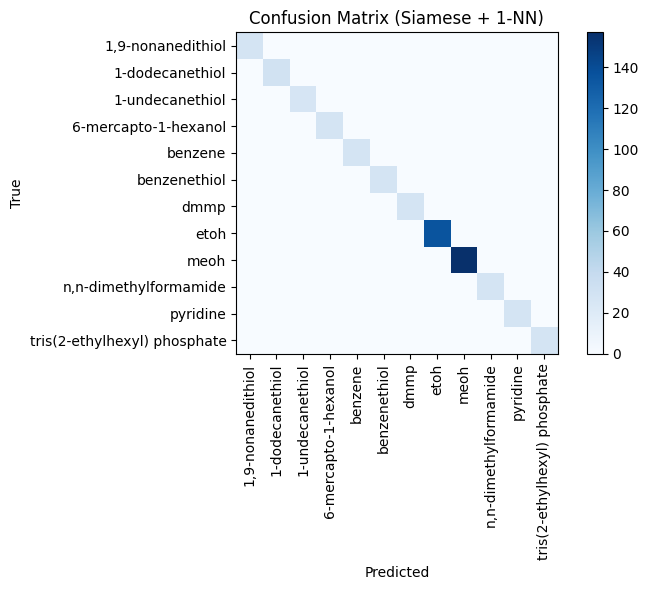

In [ ]:
# 1) Load
ref_df = pd.read_csv('reference_siamese_resampled.csv')
qry_df = pd.read_csv('reference_v2.csv')

# 2) Ensure there's a 'Label' column
for df in (ref_df, qry_df):
    if 'Label' not in df.columns:
        df.rename(columns={'Species':'Label'}, inplace=True)

# 3) Convert all wavenumber‐columns to floats (so "188.000" and "188" both become 188.0)
def floatify_cols(df):
    new_cols = []
    for c in df.columns:
        # Keep any of the exact label columns unchanged
        if c in ('Label', 'Label 1', 'Label 2'):
            new_cols.append(c)
        else:
            # Convert wavenumber strings to floats
            new_cols.append(float(c))
    df.columns = new_cols


floatify_cols(ref_df)
floatify_cols(qry_df)

# 4) Now grab the common float columns
wav_cols = sorted([c for c in ref_df.columns if c!='Label'])

# 5) Extract arrays + labels
ref_specs  = ref_df[wav_cols].values
qry_specs  = qry_df[wav_cols].values
ref_labels = ref_df['Label'].values
qry_labels = qry_df['Label'].values

# 6) Preprocess
ref_proc = preprocess(ref_specs)
qry_proc = preprocess(qry_specs)

# 7) Load model
input_len = ref_proc.shape[1]
model     = SiameseNet(input_len, embed_dim=64)
model.load_state_dict(torch.load('siamese_raman_resampled.pth'))
model.eval()

# 8) Compute embeddings
with torch.no_grad():
    ref_embeds = model(torch.tensor(ref_proc, dtype=torch.float32).unsqueeze(1)).cpu().numpy()
    qry_embeds = model(torch.tensor(qry_proc, dtype=torch.float32).unsqueeze(1)).cpu().numpy()

# 9) 1‑NN / 2‑NN classification
pred1, pred2 = [], []
for q in qry_embeds:
    d = np.linalg.norm(ref_embeds - q, axis=1)
    i = np.argsort(d)
    pred1.append(ref_labels[i[0]])
    top2 = ref_labels[i[:2]] if len(i)>1 else [ref_labels[i[0]], None]
    pred2.append(tuple(top2))

# 10) Accuracy & confusion matrix
acc1 = accuracy_score(qry_labels, pred1)
acc2 = np.mean([qry_labels[i] in p for i,p in enumerate(pred2)])
print(f"Top‑1 Acc: {acc1:.2%}, Top‑2 Acc: {acc2:.2%}")

labels_u = np.unique(qry_labels)
cm = confusion_matrix(qry_labels, pred1, labels=labels_u)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.xticks(range(len(labels_u)), labels_u, rotation=90)
plt.yticks(range(len(labels_u)), labels_u)
plt.colorbar()
plt.title('Confusion Matrix (Siamese + 1‑NN)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
